In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.formula.api as smf
import warnings

warnings.filterwarnings("ignore")

EVENT_DATES = [
    '2017-10-16', '2019-02-28', '2019-12-08', '2020-01-02', '2020-10-14',
    '2020-12-01', '2021-04-15', '2021-08-05', '2021-10-27', '2021-12-09',
    '2022-06-30', '2022-09-06', '2022-09-15', '2024-03-13',
]

QUANTILES = [0.1, 0.5, 0.9]
WINDOW = 30
DAYS_AFTER_EVENT = 0  # adjust as needed

crix_df = pd.read_csv(
    "../Data/crix_df.csv",
    index_col=0,
    parse_dates=True,
)

# Ensure DatetimeIndex
crix_df.index = pd.to_datetime(crix_df.index)

In [4]:
def compute_rolling_quantile_betas(crix_df, quantiles=(0.1, 0.5, 0.9), window=30):
    """
    Fit rolling-window quantile regressions of ETH return on CRIX return,
    tracking how the intercept and slope evolve over time at each quantile.
    """
    rolling_params = {q: {'Intercept': [], 'crix_return': []} for q in quantiles}

    for start in range(0, len(crix_df) - window):
        window_data = crix_df.iloc[start:start + window]
        for q in quantiles:
            mod = smf.quantreg('eth_return ~ crix_return', window_data)
            res = mod.fit(q=q)
            rolling_params[q]['Intercept'].append(res.params['Intercept'])
            rolling_params[q]['crix_return'].append(res.params['crix_return'])

    rolling_index = crix_df.index[window - 1:-1]
    rolling_dfs = {
        q: pd.DataFrame(data, index=rolling_index) for q, data in rolling_params.items()
    }
    return rolling_dfs


def mean_beta_after_events(rolling_dfs, event_dates, quantile=0.9, days_after=0):
    """
    For a chosen quantile's rolling beta series, compute the mean
    beta value in a short window starting at each event date.
    """
    data = rolling_dfs[quantile]
    event_dates = pd.to_datetime(event_dates)
    mean_after_event = {}

    for event_date in event_dates:
        start_date = event_date
        end_date = event_date + pd.Timedelta(days=days_after)

        if end_date in data.index:
            values = data.loc[start_date:end_date]
        else:
            values = data.loc[start_date:]

        mean_after_event[event_date] = values.mean()

    return pd.DataFrame(mean_after_event).T


def plot_rolling_betas(rolling_dfs, quantiles, event_dates, save_path=None):
    """
    Plot rolling CRIX-return coefficients (betas) for each quantile,
    with event dates marked as vertical reference lines.
    """
    plt.rcParams['font.family'] = 'serif'
    colors = ['green', 'blue', 'red']

    fig, ax = plt.subplots(figsize=(16, 6))

    for i, q in enumerate(quantiles):
        ax.plot(
            rolling_dfs[q].index,
            rolling_dfs[q]['crix_return'],
            color=colors[i % len(colors)],
            linewidth=1,
            label=f'q={q}',
        )

    for d in event_dates:
        ax.axvline(pd.to_datetime(d), color='#7f7f7f', linestyle=':', linewidth=0.5)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

    ax.set_ylabel('Coefficient', fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=12, frameon=False)

    fig.patch.set_alpha(0)
    ax.set_facecolor('none')
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=200, transparent=True)

    plt.show()
    return fig

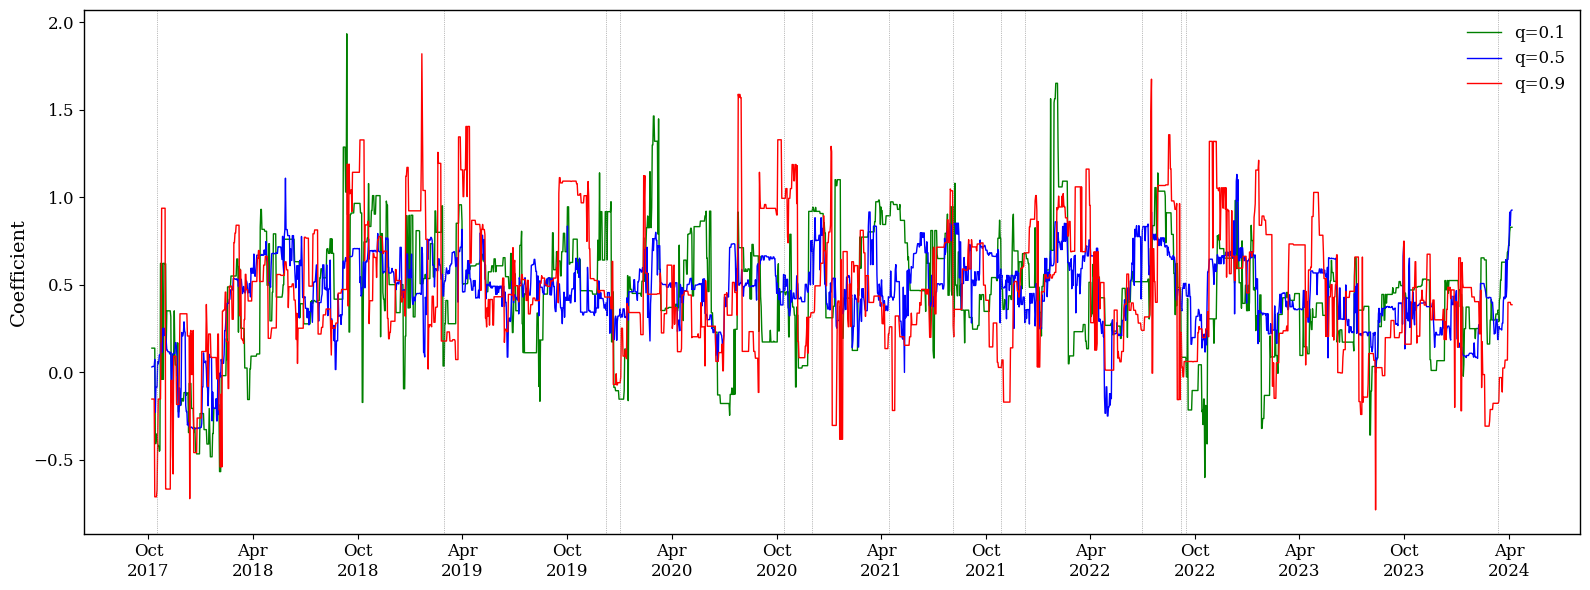

In [5]:
rolling_dfs = compute_rolling_quantile_betas(crix_df, quantiles=QUANTILES, window=WINDOW)
event_summary = mean_beta_after_events(rolling_dfs, EVENT_DATES, quantile=0.9)
fig = plot_rolling_betas(rolling_dfs, QUANTILES, EVENT_DATES, save_path="rolling_betas.png")